In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (input_file_name, 
regexp_extract, col, to_date, avg, udf, regexp_replace, trim,least, lit, mean as _mean, expr,date_format)
from pyspark.sql.types import DoubleType, StringType
from typing import List, Dict, Tuple
import glob

import gzip
from functools import reduce

In [2]:
# --- 1. Spark Session Initialization ---
# This is required to run PySpark.
# Depending on your environment, you might need a more complex config.
spark = SparkSession.builder.appName("AvailabilityAnalysisSpark").getOrCreate()
print(f"Spark Version: {spark.version}")


Spark Version: 4.0.0-preview2


In [3]:

# --- CONFIGURATION ---
COLUMN = "availability_365"
# IMPORTANT: Adjust this to the actual base directory on your cluster/machine.
# For the example file path `/mnt/data/public/insideairbnb/...`, the ROOT_DIR would be `/mnt/data/public/insideairbnb`
ROOT_DIR = "" 
# Note: For testing locally, you would need to adjust this to a local path
# that contains the city folders, e.g., ROOT_DIR = "./data"

# Define the base of the path that is NOT the city-specific key
PATH_PREFIX = "mnt/data/public/insideairbnb/data.insideairbnb.com/"

START_DATE = "2019-01-01"
END_DATE = "2021-12-31"

CITY_CONFIGS = [
    {
        "label": "new-york-city",
        # The full path segment for the glob pattern
        "root_path": f"{PATH_PREFIX}united-states/ny/new-york-city",
        # NEW KEY: The EXACT path segment expected by the regex output (city_label_raw)
        "regex_key": "united-states/ny/new-york-city", 
        "start": "2019-01-09",
        "end": "2021-08-04",
    },
    {
        "label": "austin",
        "root_path": f"{PATH_PREFIX}united-states/tx/austin",
        "regex_key": "united-states/tx/austin",
        "start": "2019-01-14",
        "end": "2021-07-08",
    },
    {
        "label": "los-angeles",
        "root_path": f"{PATH_PREFIX}united-states/ca/los-angeles",
        "regex_key": "united-states/ca/los-angeles",
        "start": "2019-01-11",
        "end": "2021-08-07",
    },
]

In [4]:
import gzip
import re

def read_file_to_spark_df(spark, filepath: str, target_column: str, date_pattern: str):
    """
    Read a single CSV file using Python (handles gzip issues), 
    then convert to Spark DataFrame for distributed processing.
    Returns None if file can't be read or column doesn't exist.
    """
    # Extract date from filepath
    match = re.search(date_pattern, filepath)
    if not match:
        return None
    file_date = match.group(1)
    
    # Try reading with gzip
    try:
        with gzip.open(filepath, 'rt', encoding='utf-8', errors='ignore') as f:
            pdf = pd.read_csv(f, usecols=[target_column], dtype={target_column: float})
    except:
        # Try as plain CSV
        try:
            pdf = pd.read_csv(filepath, usecols=[target_column], dtype={target_column: float})
        except:
            return None
    
    if target_column not in pdf.columns:
        return None
    
    # Add date column
    pdf["date"] = file_date
    
    # Convert to Spark DataFrame
    return spark.createDataFrame(pdf)


def collect_daily_availability_spark(
    city_configs: List[Dict], column: str, base_dir: str, start_date: str, end_date: str
) -> pd.DataFrame:
    """
    Collects daily means of a column for multiple cities using Spark,
    filtering by a specified date range.
    """
    results = []
    daily_mean_col = f"{column}_mean"
    
    for cfg in city_configs:
        label = cfg["label"]
        root_path = cfg["root_path"]
        regex_key = cfg["regex_key"]
        
        all_files = glob.glob(f"{base_dir}/{root_path}/*/data/listings.csv.gz")
        print(f"[{label}] Files found: {len(all_files)}")
        
        if not all_files:
            print(f"[{label}] No files found.")
            continue
        
        date_pattern = rf"{regex_key}/(\d{{4}}-\d{{2}}-\d{{2}})"
        
        # Read all files into Spark DataFrames
        spark_dfs = []
        failed = []
        
        for filepath in all_files:
            sdf = read_file_to_spark_df(spark, filepath, column, date_pattern)
            if sdf is not None:
                spark_dfs.append(sdf)
            else:
                failed.append(filepath.split('/')[-3])
        
        print(f"[{label}] Read: {len(spark_dfs)}, Failed: {len(failed)}")
        if failed:
            print(f"[{label}] Skipped: {failed[:5]}{'...' if len(failed) > 5 else ''}")
        
        if not spark_dfs:
            continue
        
        # Union all Spark DataFrames
        from functools import reduce
        df = reduce(lambda a, b: a.union(b), spark_dfs)
        
        # Convert date string to date type
        df = df.withColumn("date", to_date(col("date")))
        
        # Date range filter
        df = df.filter(
            (col("date") >= lit(start_date)) & 
            (col("date") <= lit(end_date))
        )
        
        # Filter invalid values
        df = df.filter(col(column).isNotNull())
        if "availability" in column:
            df = df.filter((col(column) >= 0) & (col(column) <= 365))
        
        # Aggregate by date (runs distributed on Spark)
        daily = (
            df.groupBy("date")
            .agg(_mean(column).alias(daily_mean_col))
            .withColumn("city_label", lit(label))
            .withColumn("month", date_format(col("date"), "yyyy-MM"))
            .orderBy("date")
        )
        
        # Only convert final aggregated result to Pandas (small)
        results.append(daily.toPandas())
    
    if results:
        final_df = pd.concat(results, ignore_index=True)
        return final_df.sort_values(["city_label", "date"]).reset_index(drop=True)
    
    return pd.DataFrame(columns=["city_label", "date", "month", daily_mean_col])

In [ ]:
# Plot multiple cities: monthly average availability
def plot_multi_city_monthly_availability(city_results: List[Tuple[str, pd.DataFrame]], column: str,
                                         outfile="images/availability_mean.png"):
    plt.figure(figsize=(12, 6))
    
    # Key dates to mark
    IMPORTANT_DATES = [
        "2020-05-10",   # WHO pandemic declaration
        "2021-01-01",   # example lockdown marker
    ]
    for d in IMPORTANT_DATES:
        try:
            dt = pd.to_datetime(d, format="%Y-%m-%d")
        except Exception as e:
            print(f"Skipping invalid date '{d}': {e}")
            continue
        plt.axvline(dt, linestyle="--", linewidth=1)
        plt.text(dt, 0, d, rotation=90, va="bottom")
    
    for label, month_df in city_results:
        if month_df.empty:
            print(f"Skipping plot for {label}: no data.")
            continue
        
        df = month_df.copy()
        df["month_dt"] = pd.to_datetime(df["date"])
        
        # FIX: Use the correct column name from collect_daily_availability_spark
        # The Spark function outputs "{column}_mean", not "{column}_mean_month"
        col_name = f"{column}_mean"
        
        # Fallback: check if the column exists, try alternative names
        if col_name not in df.columns:
            alt_name = f"{column}_mean_month"
            if alt_name in df.columns:
                col_name = alt_name
            else:
                print(f"[{label}] Column '{col_name}' not found. Available: {list(df.columns)}")
                continue
        
        plt.plot(df["month_dt"], df[col_name], marker="o", label=label)
    
    plt.title("Monthly Average Availability by City")
    plt.xlabel("Month")
    plt.ylabel("Average Availability (days per listing)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved figure to {outfile}")

In [ ]:
# Plot multiple cities: yearly average availability
def plot_yearly_mean_bars(city_results: List[Tuple[str, pd.DataFrame]], column: str,
                          outfile="images/availability_mean_bar.png"):
    """
    Bar chart of yearly average availability (2019, 2020, 2021)
    with numerical labels on each bar.
    """
    all_rows = []
    col_name = f"{column}_mean"  # Fixed: matches collect_daily_availability_spark output
    
    for label, month_df in city_results:
        if month_df.empty:
            continue
        df = month_df.copy()
        
        # Fix: Handle both datetime and string date columns
        if pd.api.types.is_datetime64_any_dtype(df["date"]):
            df["year"] = df["date"].dt.year.astype(str)
        else:
            df["year"] = df["date"].astype(str).str.slice(0, 4)
        
        yearly = (
            df.groupby("year")[col_name]
            .mean()
            .reindex(["2019", "2020", "2021"])
        )
        all_rows.append((label, yearly))
    
    # Plot
    plt.figure(figsize=(10, 6))
    years = ["2019", "2020", "2021"]
    x = range(len(years))
    bar_width = 0.25
    offset_index = 0
    
    for label, yearly_series in all_rows:
        y_vals = yearly_series.values
        x_positions = [i + offset_index * bar_width for i in x]
        bars = plt.bar(x_positions, y_vals, width=bar_width, label=label)
        
        # Add numerical labels above bars
        for bar, value in zip(bars, y_vals):
            if pd.isna(value):
                continue
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
        offset_index += 1
    
    plt.xticks([i + bar_width * (len(all_rows) - 1) / 2 for i in x], years)
    plt.ylabel("Average Availability (days)")
    plt.title("Yearly Average Availability (2019–2021)")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(outfile, dpi=150)
    plt.show()
    print(f"Saved bar chart to {outfile}")

[new-york-city] Files found: 83
[new-york-city] Read: 83, Failed: 0
[austin] Files found: 47
[austin] Read: 47, Failed: 0
[los-angeles] Files found: 61
[los-angeles] Read: 45, Failed: 16
[los-angeles] Skipped: ['2018-10-05', '2018-09-08', '2018-08-07', '2018-07-05', '2018-06-06']...

new-york-city monthly rows: 32
          date  availability_365_mean     city_label    month
57  2019-01-09             124.929866  new-york-city  2019-01
58  2019-02-01             123.215617  new-york-city  2019-02
59  2019-03-06             118.296193  new-york-city  2019-03
60  2019-04-03             114.004569  new-york-city  2019-04
61  2019-05-03             112.962894  new-york-city  2019-05

austin monthly rows: 30
         date  availability_365_mean city_label    month
0  2019-01-14             140.474207     austin  2019-01
1  2019-02-06             137.102819     austin  2019-02
2  2019-03-08             133.813294     austin  2019-03
3  2019-04-11             132.556228     austin  2019-04
4 

/tmp/ipykernel_28452/1662130967.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


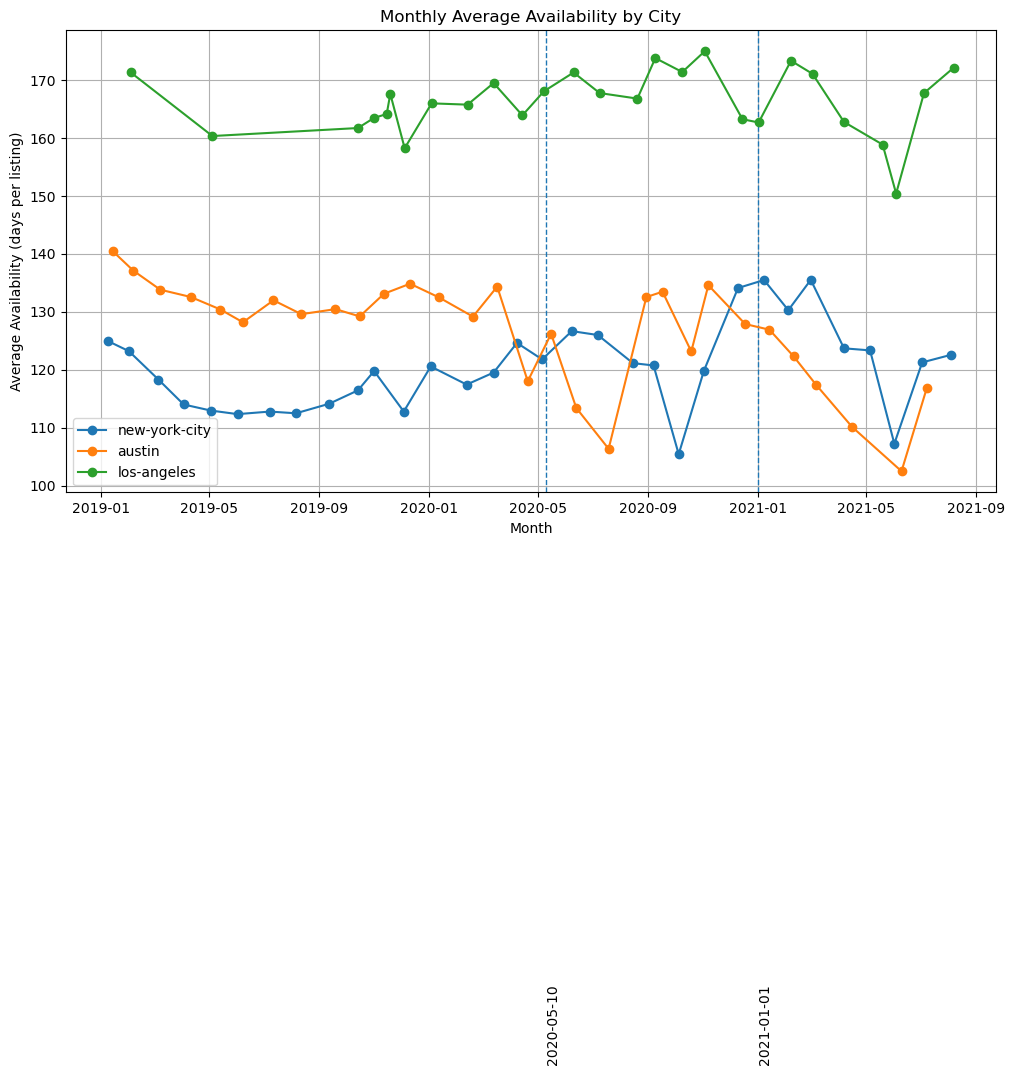

Saved figure to availability_mean.png


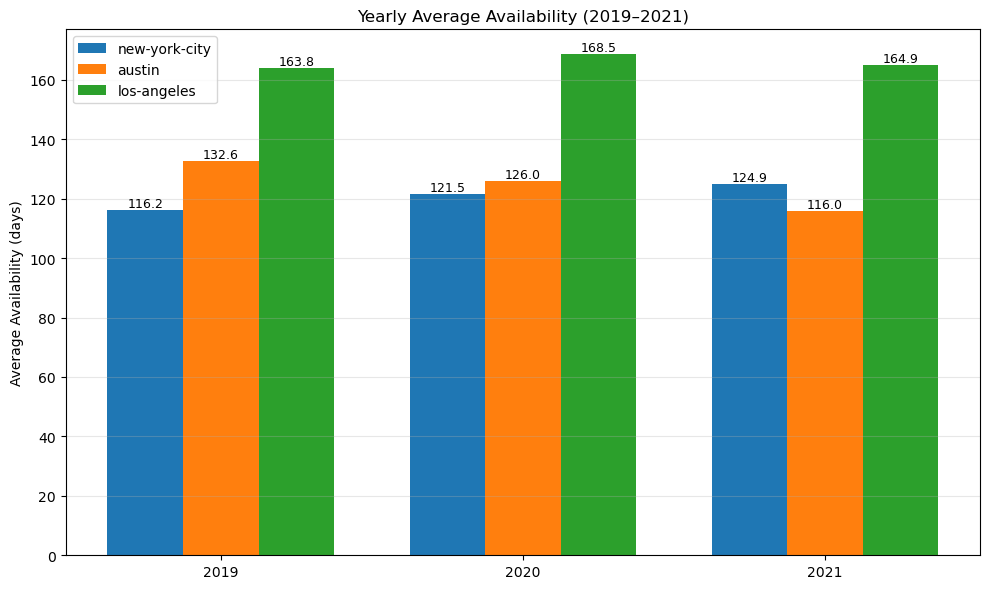

Saved bar chart to availability_mean_bar.png


In [7]:
# -------------------------------------------------------------\n
# MAIN EXECUTION BLOCK\n
# -------------------------------------------------------------\n
if __name__ == "__main__":
    
    # --- 1. Spark Processing ---
    # Perform all the heavy lifting (reading, parsing, aggregation) on the Spark cluster
    all_monthly_data_pd = collect_daily_availability_spark(
        CITY_CONFIGS, COLUMN, ROOT_DIR, START_DATE, END_DATE
    )
    
    if all_monthly_data_pd.empty:
        print("Spark job returned no data. Cannot proceed with plotting.")
        spark.stop()
        exit() # Exit if no data was processed
        
    city_results = []
    
    # --- 2. Prepare Data for Plotting ---
    # Split the resulting pandas DataFrame back into per-city DataFrames 
    for cfg in CITY_CONFIGS:
        label = cfg['label']
        
        # Filtering is safe because we checked if the combined DataFrame is empty.
        # We use .copy() to avoid SettingWithCopyWarning, though not strictly required here.
        # Check if 'city_label' exists before filtering (extra safety)
        if 'city_label' not in all_monthly_data_pd.columns:
             print(f"Error: 'city_label' column missing in combined DataFrame. Aborting for {label}.")
             continue
            
        monthly_avail = all_monthly_data_pd[all_monthly_data_pd['city_label'] == label].copy()
        
        print(f"\n{label} monthly rows:", len(monthly_avail))
        if not monthly_avail.empty:
            print(monthly_avail.head())

        # The result tuples for the plotting functions: (city_label, monthly_data_df)
        # DROP the 'city_label' column here, *after* filtering. 
        # This makes the data compatible with your original plotting functions.
        city_results.append((label, monthly_avail.drop(columns=['city_label'])))

    # --- 3. Plot Comparison ---
    if city_results:
        plot_multi_city_monthly_availability(city_results, COLUMN)
        plot_yearly_mean_bars(city_results, COLUMN)
    else:
        print("No data available to plot.")

    # Stop the Spark session when done
    spark.stop()

In [8]:
all_monthly_data_pd = collect_daily_availability_spark(
        CITY_CONFIGS, COLUMN, ROOT_DIR
    )
all_monthly_data_pd.show()

TypeError: collect_daily_availability_spark() missing 2 required positional arguments: 'start_date' and 'end_date'